In [1]:
import time
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
def get_countrate(integration_time: float = 0.5, APD=2):
    countrate = tagger.countrate()
    time.sleep(integration_time)
    return float(countrate.getData()[APD-1])
    # print(f"{countrate.getData()[1]*1e-3:.1f} kCts/s")

In [3]:
voltages = np.linspace(0.75, 3, 50)
counts = []

switch_combiner.set_state('Laser_520', 'on')
for voltage in voltages:
    process_setpoint_combiner.set_setpoint('laser_power_520', voltage)
    counts.append(get_countrate())
    
process_setpoint_combiner.set_setpoint('laser_power_520', 0)
counts = np.array(counts)

NameError: name 'tagger' is not defined

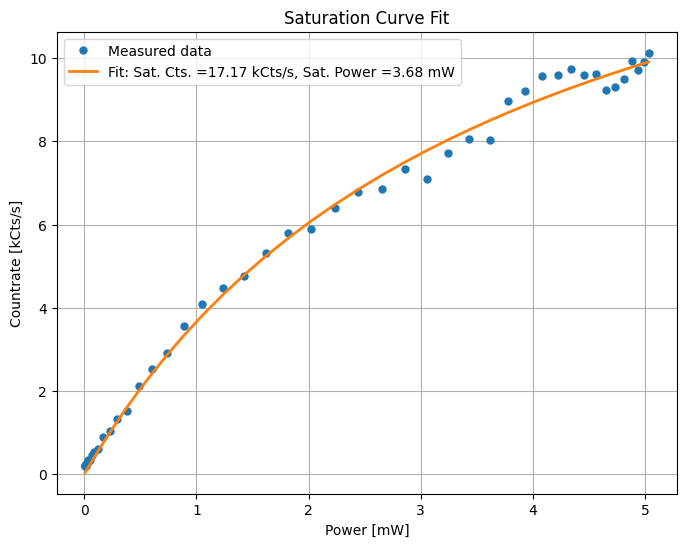

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Example data: Replace these with your actual power and countrate arrays

# Define the saturation function
def saturation_curve(x, A, B):
    return (A * x) / (B + x)

# Fit the curve
popt, pcov = curve_fit(saturation_curve, powers, counts, p0=[max(counts), np.median(powers)])

# Extract the parameters
A, B = popt

# Generate fitted data
fitted_countrate = saturation_curve(powers, *popt)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.plot(powers*1e3, counts*1e-3, 'o', label='Measured data', markersize=5)
plt.plot(powers*1e3, fitted_countrate*1e-3, '-', label=f'Fit: Sat. Cts. ={A*1e-3:.2f} kCts/s, Sat. Power ={B*1e3:.2f} mW', linewidth=2)

# Label the plot
plt.xlabel("Power [mW]")
plt.ylabel("Countrate [kCts/s]")
plt.title("Saturation Curve Fit")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def measure_power(min_voltage=0.75, max_voltage=3, steps=50):
    switch_combiner.set_state('flip_powermeter', 'in')
    powermeter.set_activity_state("Power", True)
    switch_combiner.set_state('Laser_520', 'on')
    
    time.sleep(2)
    
    voltages = np.linspace(min_voltage, max_voltage, steps)
    powers = []
    for voltage in voltages:
        process_setpoint_combiner.set_setpoint('laser_power_520', voltage)
        time.sleep(0.2)
        powers.append(powermeter.get_process_value("Power"))

    switch_combiner.set_state('flip_powermeter', 'out')
    return voltages, np.array(powers) 
        
    

In [7]:
voltages, powers = measure_power()

In [46]:
def aom_power(V, P_max, V_s, n, alpha, offset):
    """
    Refined AOM power output model with additional saturation flexibility.
    
    Parameters:
    - V: Control voltage (array or scalar)
    - P_max: Maximum optical power output
    - V_s: Saturation voltage
    - n: Exponent for voltage dependence
    - alpha: Controls saturation sharpness
    - offset: Baseline offset for the power

    Returns:
    - Optical power output P(V)
    """
    return P_max * (V**n) / ((V**n + V_s**n)**alpha) + offset

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model

# Define the AOM power output model

# Create the lmfit-based class
class AOMPowerFit:
    """
    Class to handle AOM power fitting using the refined model with lmfit.
    """

    def __init__(self, V_data, P_data, model=None, init_guess_func=None):
        """
        Initialize with voltage and power data.
        """
        self.V_data = np.array(V_data)
        self.P_data = np.array(P_data)
        self.init_guess_func = init_guess_func
        
        if not model:
            self.model = Model(self.aom_power)  # Initialize the model
            self.init_guess_func = self.aom_power_init_guess_func
            
    @staticmethod
    def aom_power(V, P_max, V_s, n, alpha, offset, init_guess_func=None):
        """
        Refined AOM power output model with additional saturation flexibility.
        """
        return P_max * (V**n) / ((V**n + V_s**n)**alpha) + offset
    
    @staticmethod
    def aom_power_init_guess_func(V_data, P_data):
        
        P_max_guess = max(P_data)  # Max observed power
        V_s_guess = V_data[np.argmax(P_data)]/2  # Voltage at max power
        n_guess = 2.0  # Start with quadratic behavior
        alpha_guess = 1.0  # Default sharpness factor
        offset_guess = min(P_data)  # Baseline offset
        return {
            "P_max": P_max_guess,
            "V_s": V_s_guess,
            "n": n_guess,
            "alpha": alpha_guess,
            "offset": offset_guess
        }

    
    def get_initial_guesses(self):
        """
        Generate initial guesses dynamically based on the input data.
        """
        return self.init_guess_func(self.V_data, self.P_data)

        
    def fit_data(self):
        """
        Fit the AOM power model to the data using lmfit.
        """
        if self.init_guess_func:
            params = self.model.make_params(**self.get_initial_guesses())
        else:
            params = self.model.make_params()

        # Perform the fit
        self.result = self.model.fit(self.P_data, params, V=self.V_data)
        return self.result

    def plot_fit(self):
        """
        Plot the measured data and the fitted curve.
        """
        if not hasattr(self, 'result'):
            raise ValueError("Fit the data first using `fit_data()`.")
        
        # Generate the fitted curve
        V_fit = np.linspace(min(self.V_data), max(self.V_data), 500)
        P_fit = aom_power(V_fit, **self.result.best_values)

        # Plot
        plt.figure(figsize=(8, 6))
        plt.scatter(self.V_data, self.P_data, label="Measured Data", color="blue", s=10)
        plt.plot(V_fit, P_fit, label="Fitted Curve", color="orange", linewidth=2)
        plt.xlabel("Voltage [V]")
        plt.ylabel("Power [mW]")
        plt.title("Voltage to Power Calibration")
        plt.legend()
        plt.grid()
        plt.show()

    def print_fit_report(self):
        """
        Print the fit report.
        """
        if not hasattr(self, 'result'):
            raise ValueError("Fit the data first using `fit_data()`.")
        print(self.result.fit_report())

[[Model]]
    Model(aom_power)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 357
    # data points      = 50
    # variables        = 5
    chi-square         = 3.3630e-11
    reduced chi-square = 7.4734e-13
    Akaike info crit   = -1391.38109
    Bayesian info crit = -1381.82097
    R-squared          = 0.99986331
[[Variables]]
    P_max:   1.8386e-04 +/- 3.1230e-05 (16.99%) (init = 0.0001981265)
    V_s:     0.62477230 +/- 0.06790646 (10.87%) (init = 0.25)
    n:       2.32441097 +/- 0.03690977 (1.59%) (init = 2)
    alpha:   2.64053548 +/- 0.44198149 (16.74%) (init = 1)
    offset:  5.8568e-06 +/- 3.5797e-07 (6.11%) (init = 4.809911e-06)
[[Correlations]] (unreported correlations are < 0.100)
    C(V_s, alpha)    = +0.9985
    C(P_max, V_s)    = +0.9874
    C(P_max, n)      = -0.9786
    C(P_max, alpha)  = +0.9774
    C(V_s, n)        = -0.9376
    C(n, alpha)      = -0.9190
    C(n, offset)     = +0.6702
    C(P_max, offset) = -0.5774
    C(V_s, offse

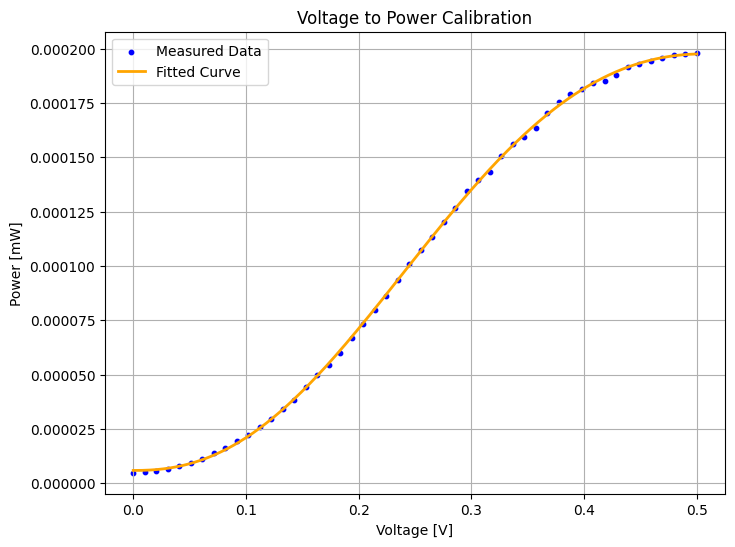

In [74]:
aom_fit = AOMPowerFit(voltages, powers)

# Fit the data
result = aom_fit.fit_data()

# Print the fit report
aom_fit.print_fit_report()

# Plot the result
aom_fit.plot_fit()

In [72]:
aom_fit.get_initial_guesses()

{'P_max': 0.00019812654, 'V_s': 0.25, 'n': 2.0, 'alpha': 1.0, 'offset': 4.8099114e-06}

In [55]:
def model(v, a, b, c):
    return a * v**2 + b * v + c

def calibrate_AOM_power(aom_channel, aom_power_channel, fit_func, laser_channel=None, voltage_steps=50):
    switch_combiner.set_state('flip_powermeter', 'in')
    powermeter.set_activity_state("Power", True)
    time.sleep(2)

    if laser_channel:
        switch_combiner.set_state(laser_channel, 'on') 
    switch_combiner.set_state(aom_channel, 'on')
    
    min_v, max_v = process_setpoint_combiner.constraints.channel_limits[aom_power_channel]
    voltages = np.linspace(min_v, max_v, voltage_steps)
    
    powers = []
    for voltage in voltages:
        process_setpoint_combiner.set_setpoint(aom_power_channel, voltage)
        time.sleep(.2)
        powers.append(powermeter.get_process_value("Power"))

    switch_combiner.set_state('flip_powermeter', 'out')

    popt, pcov = curve_fit(fit_func, voltages, powers, p0=[max(powers), max(voltages)/2, 2, 1, min(powers)])

    if laser_channel:
        switch_combiner.set_state(laser_channel, 'off') 
    switch_combiner.set_state(aom_channel, 'off')
    
    return voltages, np.array(powers), popt 
    

In [56]:
voltages, powers, popt = calibrate_AOM_power("AOM_620_2", "AOM_620_2_power", aom_power)

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1200.

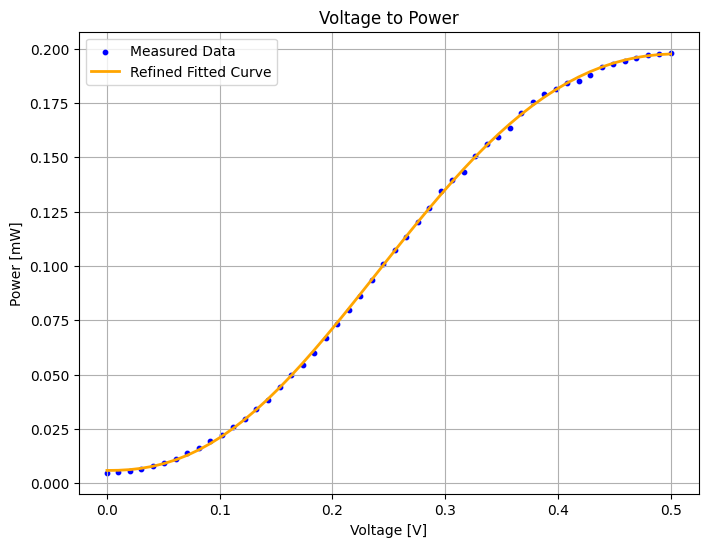

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(voltages, powers*1e3, label="Measured Data", color="blue", s=10)
plt.plot(voltages, aom_power(voltages, *popt) *1e3, label="Refined Fitted Curve", color="orange", linewidth=2)
plt.xlabel("Voltage [V]")
plt.ylabel("Power [mW]")
plt.title("Voltage to Power")
plt.legend()
plt.grid()
plt.show()